# 문자열 이상치 탐지 — thefuzz + elbow

CER 대신 `thefuzz`(구 fuzzywuzzy) 문자열 유사도로 정답↔예측을 비교하고,
**elbow 기법으로 유사도 구간의 경계(k)를 데이터 기반으로 결정**해 이상치를 탐지·검수한다.

## 전체 흐름
1. **유사도 측정** — `thefuzz.ratio` (0=무관 ~ 100=동일). CER 과 달리 0~100 bounded → 극단값 문제 없음
2. **분포 확인** — ratio 히스토그램
3. **elbow 로 k 산출** — ratio 를 k-means, inertia 꺾이는 지점이 최적 k
4. **클러스터링** — 유사도 구간별 분류 (클러스터 0 = 가장 안 닮음 = 이상치)
5. **유형 분류** — 보조 지표(`token_set`/`len_ratio`)로 반복환각/장황/누락/무관 구분
6. **교차 분석** — 어느 클러스터에 어떤 유형이 몰리는가
7. **검수** — 발화·오디오로 데이터 품질 확정

*서버에서 실행 · GPU 불필요*

In [1]:
# 의존성 (최초 1회). thefuzz = fuzzywuzzy 후속.
try:
    from thefuzz import fuzz
    import sklearn, matplotlib
    print("ok")
except ImportError:
    import subprocess
    subprocess.run(["uv", "pip", "install", "thefuzz", "python-Levenshtein",
                    "scikit-learn", "matplotlib"])
    from thefuzz import fuzz

ok


## 1~2. 유사도 측정 + 분포 확인

In [2]:
import json, unicodedata
import numpy as np
import pandas as pd
from pathlib import Path

REPO = Path("/home/kiho/workspace/TRAIN-ASR")
BENCH_ID = "AIHub_LowQualityPhoneVoice_phone_8k"   # ← 분석할 벤치마크로 변경
RESULT = REPO / "BENCHMARK" / "results" / f"whisper_small__{BENCH_ID}"

pred = list(RESULT.rglob("predictions.jsonl"))[0]
df = pd.DataFrame(json.loads(l) for l in pred.read_text(encoding="utf-8").splitlines() if l)

# 한글 비교 안정성을 위해 NFC 정규화
nfc = lambda s: unicodedata.normalize("NFC", str(s))
df["ref"] = df["text_normalized"].map(nfc)
df["hyp"] = df["prediction_normalized"].map(nfc)
df = df[df["ref"].str.strip() != ""].reset_index(drop=True)
print(f"{len(df)}건 로드")

2000건 로드


In [3]:
from thefuzz import fuzz

df["ratio"]   = [fuzz.ratio(r, h)            for r, h in zip(df.ref, df.hyp)]  # 전체 유사도 (낮을수록 이상)
df["tok_set"] = [fuzz.token_set_ratio(r, h) for r, h in zip(df.ref, df.hyp)]  # 중복·어순 무시 → 반복환각 탐지
df["len_ratio"] = df["hyp"].str.len() / df["ref"].str.len().clip(lower=1)     # 예측/정답 길이비

print(df[["ratio", "tok_set", "len_ratio"]].describe().round(1))

        ratio  tok_set  len_ratio
count  2000.0   2000.0     2000.0
mean     68.3     70.5        1.3
std      24.9     26.0        4.2
min       0.0      0.0        0.0
25%      58.0     58.0        0.8
50%      76.0     78.0        0.9
75%      86.0     90.0        1.0
max     100.0    100.0      111.0


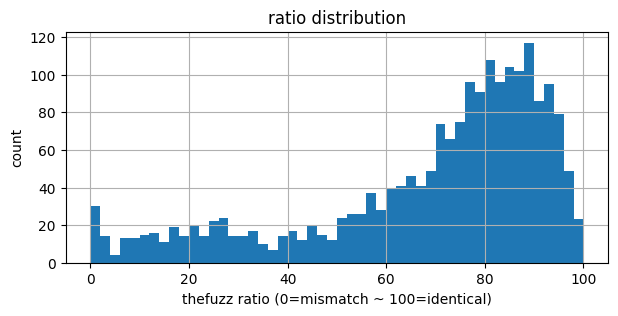

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
plt.hist(df["ratio"], bins=50)
plt.xlabel("thefuzz ratio (0=mismatch ~ 100=identical)"); plt.ylabel("count")
plt.title("ratio distribution"); plt.grid(True); plt.show()

## 3. Elbow 로 k 산출

ratio(0~100, bounded)를 k-means → inertia 가 급격히 줄다 완만해지는 꺾임점이 최적 k.
CER 과 달리 극단값이 없어 elbow 가 깔끔하게 나온다.

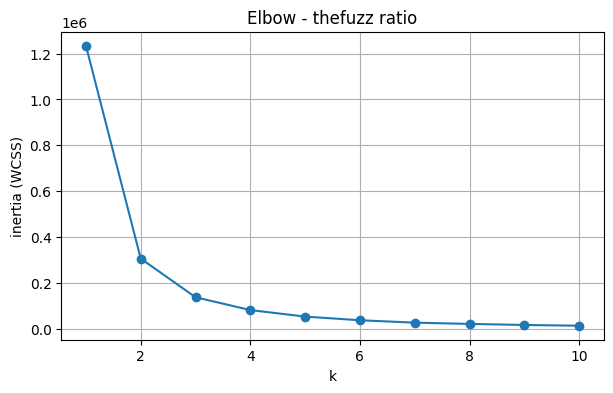

kneed 미설치 — 그래프 보고 K 직접 지정


In [5]:
from sklearn.cluster import KMeans

X = df["ratio"].values.reshape(-1, 1)
ks = range(1, 11)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, "o-")
plt.xlabel("k"); plt.ylabel("inertia (WCSS)")
plt.title("Elbow - thefuzz ratio"); plt.grid(True); plt.show()

try:
    from kneed import KneeLocator
    best_k = KneeLocator(list(ks), inertias, curve="convex", direction="decreasing").elbow
    print(f"자동 추천 elbow k = {best_k}")
except ImportError:
    print("kneed 미설치 — 그래프 보고 K 직접 지정")
    best_k = None

## 4. 클러스터링 (유사도 구간 분류)

클러스터 0 = ratio 최저 = 가장 안 닮음 = **이상치 1순위**.

In [6]:
K = best_k or 4                                  # ← 그래프 보고 직접 지정 가능
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)

# ratio 평균 오름차순으로 클러스터 재정렬 (0 = 가장 안 닮음 = 이상치)
df["cluster"] = km.labels_
order = df.groupby("cluster")["ratio"].mean().sort_values().index
df["cluster"] = df["cluster"].map({old: new for new, old in enumerate(order)})

print(f"K={K} 클러스터 (0=가장 이상치, ratio 낮을수록 의심):")
for c in sorted(df["cluster"].unique()):
    s = df[df["cluster"] == c]["ratio"]
    print(f"  클러스터 {c}: n={len(s):5d} | ratio {s.min():3.0f} ~ {s.max():3.0f} | 평균 {s.mean():4.1f}")

K=4 클러스터 (0=가장 이상치, ratio 낮을수록 의심):
  클러스터 0: n=  277 | ratio   0 ~  34 | 평균 17.1
  클러스터 1: n=  310 | ratio  35 ~  62 | 평균 51.9
  클러스터 2: n=  662 | ratio  63 ~  81 | 평균 73.8
  클러스터 3: n=  751 | ratio  82 ~ 100 | 평균 89.1


## 5~6. 유형 분류 + 교차 분석

각 발화가 *왜* 안 닮았는지를 보조 지표로 분류하고, 클러스터별로 어떤 유형이 몰리는지 본다.

In [7]:
def classify(r):
    # 토큰집합은 닮았는데(중복무시) 길이 폭증 → 같은 말 반복 = 반복환각
    if r["tok_set"] >= 70 and r["len_ratio"] > 3:
        return "반복환각"
    # 예측이 정답보다 훨씬 김 → 다른 발화 혼입/장황
    if r["len_ratio"] > 3:
        return "장황(타인음성?)"
    # 정답이 예측보다 훨씬 김 → 예측 누락/정렬오류
    if r["len_ratio"] < 0.4:
        return "누락(정렬오류?)"
    # 길이는 비슷한데 안 닮음 → 심각 오인식 또는 데이터결함
    return "무관(오인식/결함)"

df["type"] = df.apply(classify, axis=1)

# 클러스터 × 유형 교차표 (클러스터 0=이상치에 어떤 유형이 몰리는지)
print(pd.crosstab(df["cluster"], df["type"]))

type     누락(정렬오류?)  무관(오인식/결함)  반복환각  장황(타인음성?)
cluster                                        
0               38         182     5         52
1               10         300     0          0
2                0         662     0          0
3                0         751     0          0


## 7. 검수 — 발화 / 오디오

In [8]:
# 클러스터별 발화 확인 (ratio 낮은 순 5개)
for c in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == c]
    print(f"\n===== 클러스터 {c} (n={len(sub)}, ratio {sub.ratio.min():.0f}~{sub.ratio.max():.0f}) =====")
    for _, r in sub.sort_values("ratio").head(5).iterrows():
        print(f"  [ratio {r.ratio:3d} | {r['type']} | lenR {r.len_ratio:4.1f}] {Path(r.audio).name}")
        print(f"    정답: {r.ref[:50]}")
        print(f"    예측: {r.hyp[:50]}")


===== 클러스터 0 (n=277, ratio 0~34) =====
  [ratio   0 | 무관(오인식/결함) | lenR  0.5] S007532_0001.wav
    정답: 무엇을 도와드릴까요?
    예측: 고맙습니다
  [ratio   0 | 무관(오인식/결함) | lenR  0.5] S009300_0001.wav
    정답: 무엇을 도와드릴까요?
    예측: 고맙습니다
  [ratio   0 | 누락(정렬오류?) | lenR  0.2] S023426_0018.wav
    정답: 잠깐만요, 선생님.
    예측: 안녕
  [ratio   0 | 누락(정렬오류?) | lenR  0.1] S023606_0004.wav
    정답: 나세요 어머니 저희 쪽에서만 판매를 하고
    예측: 아아
  [ratio   0 | 무관(오인식/결함) | lenR  0.7] S005829_0131.wav
    정답: 피해가 있죠.
    예측: 고맙습니다

===== 클러스터 1 (n=310, ratio 35~62) =====
  [ratio  35 | 무관(오인식/결함) | lenR  1.1] S006810_0015.wav
    정답: 사용을 하다가.
    예측: 하영은 하다 보다
  [ratio  35 | 무관(오인식/결함) | lenR  1.3] S038569_0008.wav
    정답: 좋은 하루 되세요.
    예측: 좋아요와 구독 부탁드려요
  [ratio  35 | 무관(오인식/결함) | lenR  0.5] S005834_0011.wav
    정답: 아 한 칠십 프로요.
    예측: 한 70 야
  [ratio  35 | 무관(오인식/결함) | lenR  0.9] S008672_0002.wav
    정답: 쫌 부탁드릴게요.
    예측: 오늘도 뵙길게요
  [ratio  35 | 무관(오인식/결함) | lenR  1.1] S023500_0026.wav
    정답: 아 택배비 선불이요?
    예측: 아 3 3 2 3분이야

===